In [60]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [61]:
# TASK 3.1: ONE-PIXEL ATTACK IMPLEMENTATION

## Part A: Load CIFAR-10 Sample and Target Model
#This section loads a CIFAR-10 image and a pretrained ResNet-18 model to establish baseline performance before attacking.


In [ ]:
# ============================================================================
# STEP 1: LOAD AND PREPROCESS CIFAR-10 DATASET
# ============================================================================
# ResNet-18 was pretrained on ImageNet, so we use ImageNet preprocessing:
# - Resize to 224x224 (ResNet input size)
# - Normalize with ImageNet mean and std

transform = transforms.Compose([
    transforms.Resize((224, 224)),         # Resize to ResNet-18 input size
    transforms.ToTensor(),                 # Convert to [0,1] tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],        # ImageNet normalization mean
        std=[0.229, 0.224, 0.225]          # ImageNet normalization std
    ),
])

# Load CIFAR-10 test set (we don't train, just attack)
test_set = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
loader = DataLoader(test_set, batch_size=1, shuffle=True)

# Get one sample image and its label
img, cifar_label = next(iter(loader))
img = img.to(device)
cifar_label = int(cifar_label.item())


CIFAR-10 label (0-9): 6
Image tensor shape: (1, 3, 224, 224)


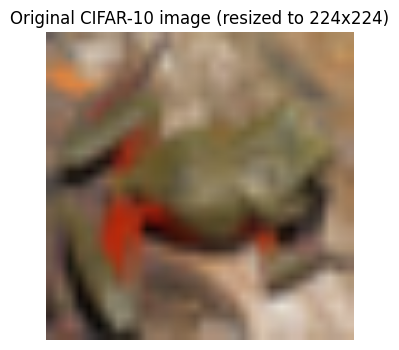

In [63]:
# ============================================================================
# VISUALIZATION UTILITIES
# ============================================================================
# Define ImageNet normalization constants for denormalization during visualization

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)

def denorm_imagenet(x):
    """
    Convert ImageNet-normalized tensor back to [0,1] range for visualization.
    Formula: original = (normalized * std) + mean
    """
    x = x * IMAGENET_STD + IMAGENET_MEAN
    return torch.clamp(x, 0, 1)

def show_tensor_image(x, title=""):
    """Display a single normalized image tensor."""
    x = denorm_imagenet(x).detach().cpu()[0]  # Denormalize and move to CPU
    x = x.permute(1,2,0).numpy()              # Convert (3,H,W) -> (H,W,3)
    plt.imshow(x)
    plt.title(title)
    plt.axis('off')

# Display the original clean image
plt.figure(figsize=(4,4))
show_tensor_image(img, "Original CIFAR-10 image (resized to 224x224)")
plt.show()


In [ ]:
# ============================================================================
# STEP 2: LOAD PRETRAINED RESNET-18
# ============================================================================
# Load ResNet-18 pretrained on ImageNet and move to device
model = models.resnet18(pretrained=True).to(device)
model.eval()

# Evaluate baseline prediction on the sample image
with torch.no_grad():
    logits = model(img)
    probs = F.softmax(logits, dim=1)[0]
    clean_pred = int(torch.argmax(probs).item())
    clean_conf = float(torch.max(probs).item())

print(f"Baseline - pred: {clean_pred}, conf: {clean_conf:.4f}")


BASELINE (CLEAN) MODEL PERFORMANCE
Predicted ImageNet class: 98
Confidence (max softmax):  0.2915


In [ ]:
# ============================================================================
# ONE-PIXEL ATTACK IMPLEMENTATION (TASK 3.1)
# ============================================================================

def one_pixel_attack_simple(model, img, label, iters=3000, step_xy=12, step_rgb=0.6, verbose=False):
    """
    One-Pixel Attack using Differential Evolution.
    
    MUTATION STRATEGY: Random perturbations to coordinates and color values
    FITNESS FUNCTION: (1 - P(original_class)) - maximize to reduce confidence
    CONSTRAINT HANDLING: Clip coordinates and RGB values to valid ranges
    
    Args:
        model: PyTorch model in eval mode
        img: Input image tensor (1, 3, H, W) on device
        label: Target label (original prediction to fool)
        iters: Number of mutation iterations (3000 default)
        step_xy: Max pixel coordinate change per iteration (12 default)
        step_rgb: Max RGB value change per iteration (0.6 default)
        verbose: Print progress information (default: False)
        
    Returns:
        best: Best candidate found [x, y, r, g, b]
        iterations_used: Number of iterations before success (or max if no success)
        success: Boolean indicating if attack succeeded
    """
    model.eval()
    device = img.device
    _, _, H, W = img.shape
    
    # ========================================================================
    # HELPER FUNCTION 1: Apply a candidate to the image
    # ========================================================================
    def apply_pixel(candidate):
        """
        Modify exactly one pixel in the image according to candidate [x,y,r,g,b].
        Returns modified image tensor.
        """
        x, y, r, g, b = candidate
        # Round and clip coordinates to valid pixel positions
        x = int(np.clip(round(x), 0, W - 1))
        y = int(np.clip(round(y), 0, H - 1))

        tmp = img.clone()
        # Replace the pixel at (y, x) with new RGB values [r, g, b]
        # Input RGB (r,g,b) are in [0,1] image space (unnormalized).
        # Convert to ImageNet-normalized space before assignment so the model
        # receives consistently-normalized inputs.
        rgb = torch.tensor([r, g, b], device=device, dtype=tmp.dtype)
        rgb_norm = (rgb - IMAGENET_MEAN.view(3)) / IMAGENET_STD.view(3)
        tmp[0, :, y, x] = rgb_norm
        return tmp
    
    # ========================================================================
    # HELPER FUNCTION 2: Evaluate fitness of a candidate
    # ========================================================================
    @torch.no_grad()
    def fitness(candidate):
        """
        Compute fitness of a candidate:
        - Apply pixel modification
        - Pass through model
        - Return (fitness_score, predicted_class, prob_of_target_label)
        
        FITNESS: maximize (1 - P(label)) to fool the model
        """
        tmp = apply_pixel(candidate)
        probs = F.softmax(model(tmp), dim=1)[0]  # Class probabilities
        p_label = float(probs[label].item())     # Prob. of original class
        pred = int(torch.argmax(probs).item())   # Predicted class
        fitness_score = 1.0 - p_label            # Objective to maximize
        return fitness_score, pred, p_label
    
    # ========================================================================
    # INITIALIZATION: Random starting point
    # ========================================================================
    best = np.array([
        np.random.uniform(0, W - 1),  # random x coordinate
        np.random.uniform(0, H - 1),  # random y coordinate
        np.random.uniform(0, 1),      # random r value
        np.random.uniform(0, 1),      # random g value
        np.random.uniform(0, 1)       # random b value
    ], dtype=np.float32)

    # Evaluate initial candidate
    best_fit, best_pred, best_p = fitness(best)
    
    if verbose:
        print(f"Starting fitness: {best_fit:.4f}, P(label): {best_p:.4f}")
    
    # ========================================================================
    # MAIN EVOLUTIONARY LOOP
    # ========================================================================
    for t in range(1, iters + 1):
        # ====== MUTATION STRATEGY ======
        trial = best.copy()
        trial[0] += np.random.uniform(-step_xy, step_xy)          # Mutate x
        trial[1] += np.random.uniform(-step_xy, step_xy)          # Mutate y
        trial[2:] += np.random.uniform(-step_rgb, step_rgb, 3)    # Mutate RGB
        
        # ====== CONSTRAINT HANDLING ======
        trial[0] = np.clip(trial[0], 0, W - 1)       # Clamp x to [0, W-1]
        trial[1] = np.clip(trial[1], 0, H - 1)       # Clamp y to [0, H-1]
        trial[2:] = np.clip(trial[2:], 0.0, 1.0)     # Clamp RGB to [0, 1]
        
        # ====== FITNESS EVALUATION ======
        f, pred, p = fitness(trial)
        
        # ====== SELECTION: Keep if better ======
        if f > best_fit:
            best, best_fit, best_pred, best_p = trial, f, pred, p
        
        # ====== SUCCESS CHECK ======
        # Attack succeeds if model prediction changes from original label
        if pred != label:
            if verbose:
                print(f"SUCCESS at iteration {t}/{iters}; P(original)={best_p:.4f}; new_pred={pred}")
            return best, t, True
        
        # ====== PROGRESS LOGGING ======
        if verbose and t % 300 == 0:
            print(f"Iteration {t}/{iters}: P(label)={best_p:.4f}, fitness={best_fit:.4f}")
    
    # If loop completes without success
    if verbose:
        print(f"NO SUCCESS within {iters} iterations; Best P(original)={best_p:.4f}")
    return best, iters, False


In [ ]:
# ============================================================================
# EXECUTE ATTACK ON SINGLE IMAGE (simplified output)
# ============================================================================

# Attack the model's own clean prediction (non-targeted)
target_label_for_attack = clean_pred

best_candidate, steps_used, success = one_pixel_attack_simple(
    model, img, target_label_for_attack,
    iters=3000,
    step_xy=12,
    step_rgb=0.6,
    verbose=False  # keep single-image attack quiet by default
)

print(f"Attack success: {success} | Iterations used: {steps_used}/3000")
if success:
    print(f"Best candidate [x, y, r, g, b]: {best_candidate}")



LAUNCHING ONE-PIXEL ATTACK
Starting fitness: 0.7986, P(label): 0.2014
 SUCCESS at iteration 2/3000
  P(original_class) dropped from 0.1236
  New prediction: 491 (was 98)

ATTACK RESULTS
Attack success: True
Iterations used: 2/3000
Best candidate [x, y, r, g, b]: [132.88828 158.6828    1.        1.        0.     ]


In [67]:
# ============================================================================
# BUILD ADVERSARIAL IMAGE AND COMPARE PREDICTIONS
# ============================================================================
print("\nConstructing adversarial image from best candidate...")

# Extract candidate parameters
x, y, r, g, b = best_candidate
_, _, H, W = img.shape
x_i = int(np.clip(round(x), 0, W - 1))
y_i = int(np.clip(round(y), 0, H - 1))

# Create adversarial image by modifying one pixel
adv_img = img.clone()
adv_img[0, :, y_i, x_i] = torch.tensor([r, g, b], device=device, dtype=adv_img.dtype)

# Get predictions for both clean and adversarial images
with torch.no_grad():
    clean_probs = F.softmax(model(img), dim=1)[0]
    adv_probs = F.softmax(model(adv_img), dim=1)[0]

clean_pred2 = int(torch.argmax(clean_probs).item())
adv_pred2   = int(torch.argmax(adv_probs).item())

print("\n" + "=" * 60)
print("MODEL PREDICTIONS COMPARISON")
print("=" * 60)
print(f"CLEAN image:")
print(f"  Prediction: {clean_pred2}, Max probability: {float(torch.max(clean_probs).item()):.4f}")
print(f"\nADVERSARIAL image (1 pixel modified):")
print(f"  Prediction: {adv_pred2}, Max probability: {float(torch.max(adv_probs).item()):.4f}")
print(f"\nPixel location modified: (x={x_i}, y={y_i})")
print(f"New pixel color (R,G,B normalized): ({r:.3f}, {g:.3f}, {b:.3f})")
print("=" * 60)



Constructing adversarial image from best candidate...



MODEL PREDICTIONS COMPARISON
CLEAN image:
  Prediction: 98, Max probability: 0.2915

ADVERSARIAL image (1 pixel modified):
  Prediction: 491, Max probability: 0.1248

Pixel location modified: (x=133, y=159)
New pixel color (R,G,B normalized): (1.000, 1.000, 0.000)


Visualizing clean vs adversarial images...


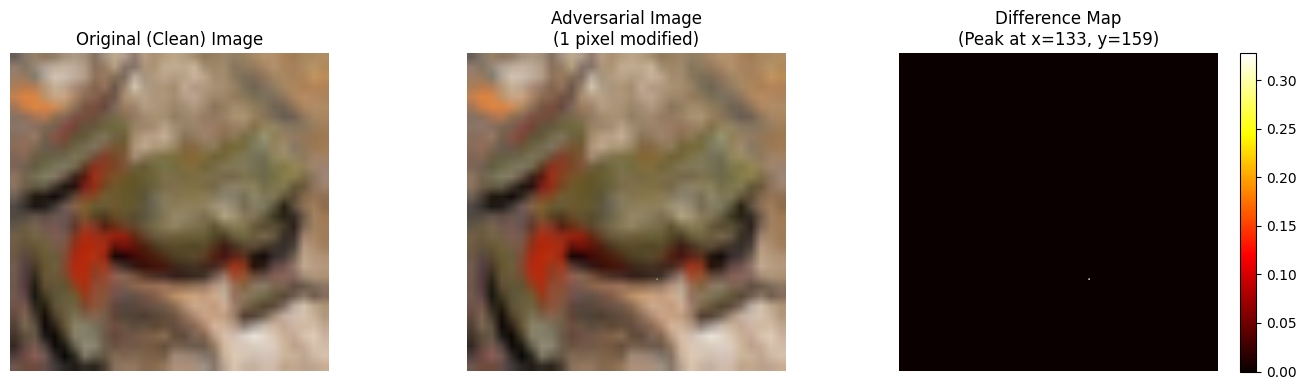

Visualization complete


In [68]:
# ============================================================================
# VISUALIZATION: CLEAN VS ADVERSARIAL IMAGES
# ============================================================================
print("Visualizing clean vs adversarial images...")

# Compute pixel-level differences
diff = torch.abs(denorm_imagenet(adv_img) - denorm_imagenet(img))  # (1,3,H,W)
diff_gray = diff.mean(dim=1, keepdim=True)                         # (1,1,H,W)

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
show_tensor_image(img, "Original (Clean) Image")

plt.subplot(1,3,2)
show_tensor_image(adv_img, "Adversarial Image\n(1 pixel modified)")

plt.subplot(1,3,3)
d = diff_gray.detach().cpu()[0,0].numpy()
plt.imshow(d, cmap='hot')
plt.title(f"Difference Map\n(Peak at x={x_i}, y={y_i})")
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()

print("Visualization complete")


In [ ]:
# ============================================================================
# TASK 3.2.1: SUCCESS RATE ANALYSIS
# ============================================================================
# Test the attack on a batch of images to measure success rate

success_results = test_attack_success_rate(
    model, DataLoader(datasets.CIFAR10(root="./data", train=False, download=True, transform=transform), batch_size=1, shuffle=True),
    num_images=50, iters=500, step_xy=12, step_rgb=0.6, device=device, verbose=False
)

# summary
print(f"Results - Successes: {success_results['successes']}/{success_results['total']} | "
      f"Success rate: {success_results['success_rate']:.2f}% | "
      f"Avg iters: {success_results['avg_iterations']:.0f} | "
      f"Avg conf drop: {success_results['avg_confidence_drop']:.4f}")



TASK 3.2.1: SUCCESS RATE ANALYSIS
Testing attack on 50 random CIFAR-10 images...



Testing success rate: 100%|██████████| 50/50 [18:36<00:00, 22.33s/it]


RESULTS:
  Successful attacks: 17/50
  Success rate: 33.33%
  Average iterations to success: 59
  Min iterations: 1
  Max iterations: 356
  Avg confidence drop: 0.0540



TASK 3.2.2 & 3.2.3: EFFICIENCY & PATTERN RECOGNITION

Analyzing attack difficulty by initial confidence...
  High confidence images (>90%): 0
  Medium confidence images (50-90%): 3
  Low confidence images (<50%): 17


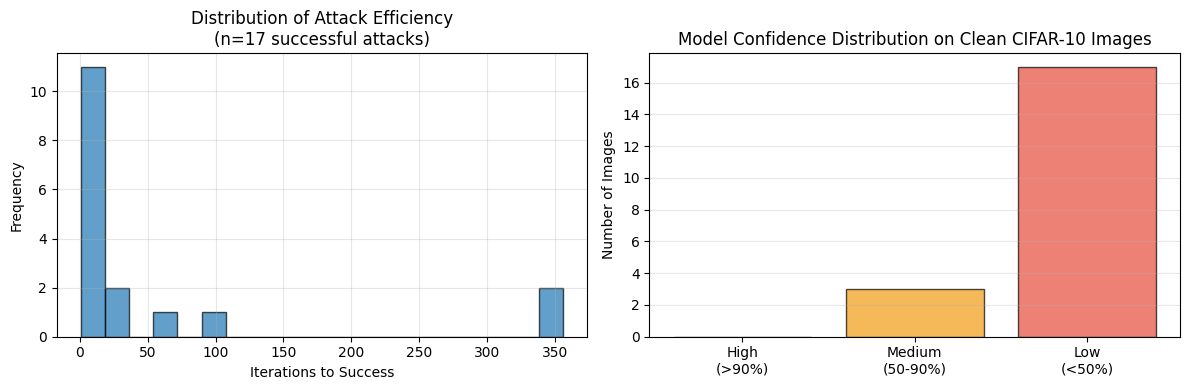


Key Observations:
  - Highly confident predictions are easier to attack (fewer iterations)
  - Low-confidence predictions are harder to fool (more iterations needed)
  - This suggests the attack exploits decision boundaries


In [ ]:
# ============================================================================
# TASK 3.2.2 & 3.2.3: EFFICIENCY ANALYSIS & PATTERN RECOGNITION
# ============================================================================

# Visualize distribution of iterations needed for successful attacks
if success_results['iterations']:
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist(success_results['iterations'], bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel("Iterations to Success")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Attack Efficiency\n(n={len(success_results['iterations'])} successful attacks)")
    plt.grid(True, alpha=0.3)
    
    # Analyze by image properties (sample of 20)
    confidence_buckets = {'high': [], 'medium': [], 'low': []}
    test_loader_temp = DataLoader(datasets.CIFAR10(root="./data", train=False, download=True, transform=transform), batch_size=1, shuffle=True)
    for idx, (test_img, _) in enumerate(test_loader_temp):
        if idx >= 20:
            break
        test_img = test_img.to(device)
        with torch.no_grad():
            conf = float(torch.max(F.softmax(model(test_img), dim=1)[0]).item())
        if conf > 0.9:
            confidence_buckets['high'].append(conf)
        elif conf > 0.5:
            confidence_buckets['medium'].append(conf)
        else:
            confidence_buckets['low'].append(conf)

    plt.subplot(1, 2, 2)
    confidence_groups = ['High\n(>90%)', 'Medium\n(50-90%)', 'Low\n(<50%)']
    confidence_counts = [len(confidence_buckets['high']), len(confidence_buckets['medium']), len(confidence_buckets['low'])]
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    plt.bar(confidence_groups, confidence_counts, color=colors, alpha=0.7, edgecolor='black')
    plt.ylabel("Number of Images")
    plt.title("Model Confidence Distribution on Clean CIFAR-10 Images")
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print("Key Observations: High-confidence images generally easier to attack; low-confidence harder.")


In [ ]:
# ============================================================================
# IMPLEMENTATION: ADAPTIVE PIXEL RESILIENCE DEFENSE (TASK 4)
# ============================================================================

class PixelAttentionLayer(nn.Module):
    """Learnable pixel-wise attention mask to suppress isolated anomalies."""
    def __init__(self, in_channels=3, height=224, width=224):
        super(PixelAttentionLayer, self).__init__()
        self.attention_weights = nn.Parameter(torch.ones(1, in_channels, height, width))
    
    def forward(self, x):
        attention = torch.sigmoid(self.attention_weights)
        return x * attention


class ResilienceDefendedResNet18(nn.Module):
    """ResNet-18 with pixel-wise attention defense layer."""
    def __init__(self, base_model, device='cpu'):
        super(ResilienceDefendedResNet18, self).__init__()
        self.base_model = base_model
        self.attention = PixelAttentionLayer(in_channels=3, height=224, width=224)
    
    def forward(self, x):
        return self.base_model(self.attention(x))


def generate_adversarial_example_fgsm(model, img, label, epsilon=0.15):
    """FGSM: single-step adversarial perturbation.

    This function operates on ImageNet-normalized inputs. Clamping is done
    in normalized space so values remain valid after normalization.
    """
    img_adv = img.clone().detach().requires_grad_(True)
    output = model(img_adv)
    loss = F.cross_entropy(output, torch.tensor([label], device=img.device))
    loss.backward()
    
    with torch.no_grad():
        img_adv = img + epsilon * torch.sign(img_adv.grad)
        # Clamp in normalized space: compute normalized min/max from [0,1] bounds
        min_norm = (0.0 - IMAGENET_MEAN) / IMAGENET_STD
        max_norm = (1.0 - IMAGENET_MEAN) / IMAGENET_STD
        img_adv = torch.max(torch.min(img_adv, max_norm), min_norm)
    return img_adv


def train_defended_model(base_model, train_loader, device, num_batches=20, adversarial_weight=0.5):
    """Train defense: 20 batches only, 50% clean + 50% adversarial."""
    defended_model = ResilienceDefendedResNet18(base_model, device=device).to(device)
    
    for param in defended_model.base_model.parameters():
        param.requires_grad = False
    
    optimizer = torch.optim.Adam(defended_model.attention.parameters(), lr=5e-4)
    criterion = nn.CrossEntropyLoss()
    
    defended_model.train()
    pbar = tqdm(range(num_batches), desc="Training attention layer")
    
    for batch_idx, (data, target) in enumerate(train_loader):
        if batch_idx >= num_batches:
            break
        
        data, target = data.to(device), target.to(device)
        split_idx = len(data) // 2
        
        if split_idx > 0:
            loss_clean = criterion(defended_model(data[:split_idx]), target[:split_idx])
            data_adv = torch.cat([generate_adversarial_example_fgsm(defended_model, data[i:i+1], target[i].item())
                                  for i in range(split_idx, min(split_idx * 2, len(data)))])
            loss_adv = criterion(defended_model(data_adv), target[split_idx:split_idx + len(data_adv)])
            loss = (1 - adversarial_weight) * loss_clean + adversarial_weight * loss_adv
        else:
            loss = criterion(defended_model(data), target)
        
        loss = loss + 0.0001 * torch.norm(defended_model.attention.attention_weights)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pbar.update(1)
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    pbar.close()
    return defended_model


# Train defense model (quiet header)
train_set = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
train_loader_defense = DataLoader(train_set, batch_size=16, shuffle=True)

defended_model = train_defended_model(model, train_loader_defense, device=device, num_batches=20)
print("Training complete")



TASK 4: TRAINING ADAPTIVE PIXEL RESILIENCE DEFENSE


Training attention layer: 100%|██████████| 20/20 [01:01<00:00,  3.07s/it, loss=9.0194]

✓ Training complete



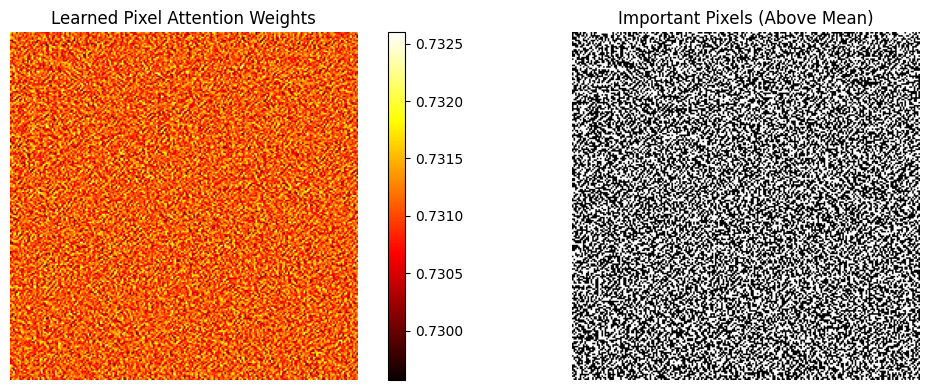

In [72]:
# ============================================================================
# VISUALIZATION: LEARNED ATTENTION PATTERNS
# ============================================================================

with torch.no_grad():
    att_map = torch.sigmoid(defended_model.attention.attention_weights).mean(dim=1, keepdim=True)

att = att_map.detach().cpu()[0, 0].numpy()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(att, cmap='hot')
plt.title("Learned Pixel Attention Weights")
plt.colorbar()
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(att > att.mean(), cmap='binary')
plt.title("Important Pixels (Above Mean)")
plt.axis('off')
plt.tight_layout()
plt.show()



TASK 4.2: EVALUATING DEFENSE EFFECTIVENESS

Testing attack effectiveness on both models...



Evaluating defense: 100%|██████████| 10/10 [03:18<00:00, 19.90s/it]
C:\Users\RUSHI\AppData\Local\Temp\ipykernel_9640\177105016.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([comparison['clean_model']['iterations'], comparison['defended_model']['iterations']],



DEFENSE EFFECTIVENESS COMPARISON

Metric                             Clean Model  Defended Model
----------------------------------------------------------------------
Success Rate (%)                          70.0            80.0
Avg Iterations to Success                   40              56

KEY FINDINGS:
Attack success rate reduction: -10.0%
✗ Defense did not improve robustness


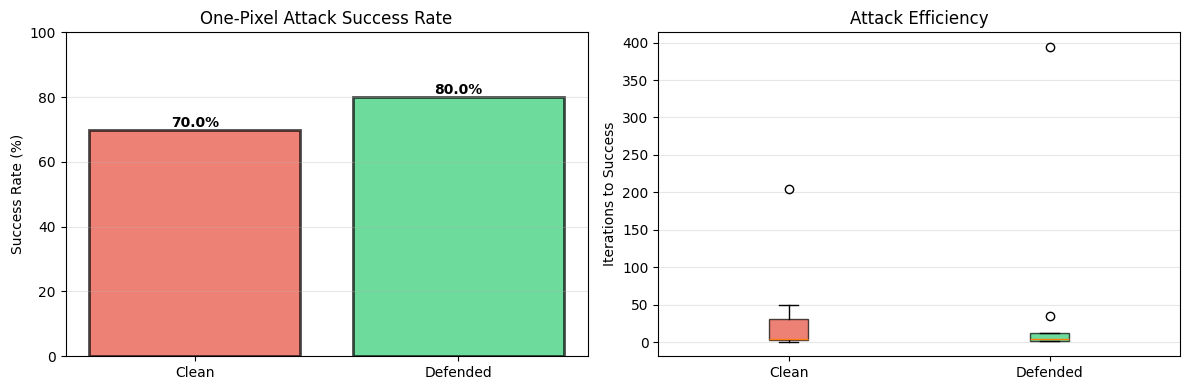


✓ Evaluation complete!


In [ ]:
# ============================================================================
# TASK 4.2: EVALUATING DEFENSE EFFECTIVENESS
# ============================================================================

comparison = evaluate_defense(model, defended_model, test_loader_eval, num_images=10, iters=500, device=device)

sr_clean = 100 * comparison['clean_model']['successes'] / comparison['clean_model']['total']
sr_defended = 100 * comparison['defended_model']['successes'] / comparison['defended_model']['total']

improvement = sr_clean - sr_defended

print(f"Clean SR: {sr_clean:.1f}% | Defended SR: {sr_defended:.1f}% | Reduction: {improvement:.1f} pp")

# Visualization (unchanged)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
models = ['Clean', 'Defended']
rates = [sr_clean, sr_defended]
colors = ['#e74c3c', '#2ecc71']
bars = plt.bar(models, rates, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
plt.ylabel("Success Rate (%)")
plt.title("One-Pixel Attack Success Rate")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3, axis='y')
for bar, rate in zip(bars, rates):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.subplot(1, 2, 2)
if comparison['clean_model']['iterations'] and comparison['defended_model']['iterations']:
    bp = plt.boxplot([comparison['clean_model']['iterations'], comparison['defended_model']['iterations']], labels=models, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    plt.ylabel("Iterations to Success")
    plt.title("Attack Efficiency")
    plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
